In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
img = cv2.imread("/content/istockphoto-465611306-612x612.jpg")

(408, 612, 3)


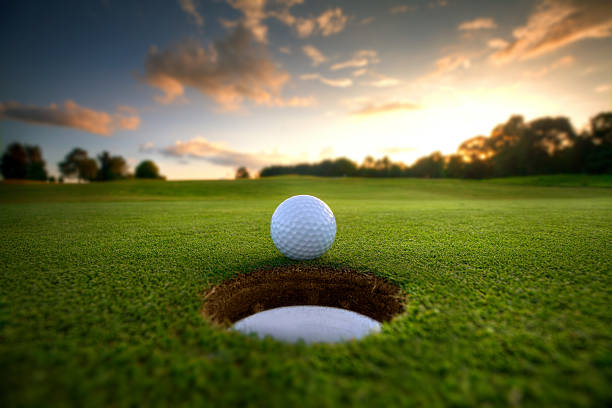

In [ ]:
print(img.shape)
height = img.shape[0]
width = img.shape[1]
cv2_imshow(img)

--- Image Dimensions ---
Original image shape: (408, 612, 3)
Color Map shape: (256, 3)
Encoded Image shape: (408, 612)

--- Compression Ratio Calculation ---
Original Size:     408x612x3 = 749,088 bytes
Compressed Size:
  - Color Map:     256x3      =       768 bytes
  - Encoded Image: 408x612x1 =   249,696 bytes
  - Total:                     =   250,464 bytes
-----------------------------------------
Compression Ratio: 749088 / 250464 = 2.9908 : 1
-----------------------------------------


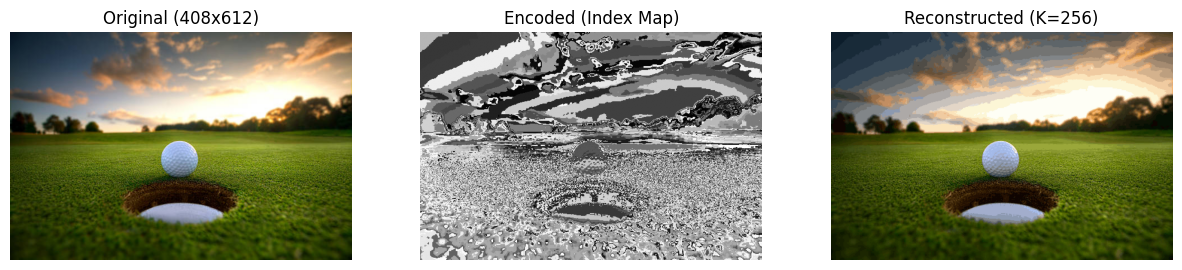

In [ ]:
K = 256
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
attempts = 10
pixel_data = img.reshape((-1, 3))
pixel_data = np.float32(pixel_data)
compactness, labels, centers = cv2.kmeans(pixel_data,
                                          K,
                                          None,
                                          criteria,
                                          attempts,
                                          cv2.KMEANS_RANDOM_CENTERS)

color_map = np.uint8(centers)
encoded_image = labels.reshape((height, width))
encoded_image_uint8 = np.uint8(encoded_image)
quantized_image = color_map[labels].reshape((height, width, 3))

print("--- Image Dimensions ---")
print(f"Original image shape: {img.shape}")
print(f"Color Map shape: {color_map.shape}")
print(f"Encoded Image shape: {encoded_image_uint8.shape}")

original_size = height * width * 3

color_map_size = K * 3
encoded_image_size = height * width * 1
total_compressed_size = color_map_size + encoded_image_size

compression_ratio = original_size / total_compressed_size

print("\n--- Compression Ratio Calculation ---")
print(f"Original Size:     {height}x{width}x3 = {original_size:,} bytes")
print(f"Compressed Size:")
print(f"  - Color Map:     {K}x3      = {color_map_size:9,} bytes")
print(f"  - Encoded Image: {height}x{width}x1 = {encoded_image_size:9,} bytes")
print(f"  - Total:                     = {total_compressed_size:9,} bytes")
print("-----------------------------------------")
print(f"Compression Ratio: {original_size} / {total_compressed_size} = {compression_ratio:.4f} : 1")
print("-----------------------------------------")



plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Original ({height}x{width})")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(encoded_image_uint8, cmap='gray')
plt.title(f"Encoded (Index Map)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(quantized_image, cv2.COLOR_BGR2RGB))
plt.title(f"Reconstructed (K=256)")
plt.axis('off')

plt.show()